In [447]:
import pandas as pd
import datetime
import requests
import matplotlib.pyplot as plt
import numpy as np

In [448]:
# - CoinGecko — 무료로 비트코인 과거 가격 데이터를 CSV 또는 API로 제공.
# - CryptoDataDownload.com — 암호화폐 과거 시세(일봉, 시간봉 등) CSV를 무료로 제공.
# - CoinMarketCap 의 Historical Data 페이지 — BTC의 과거 종가/시가/거래량 등을 확인하고 CSV로 다운로드 가능.
# → 위 출처 중 하나에서 CSV로 다운로드하거나, API를 통해 자동으로 데이터를 받아올 수 있음.

In [449]:
# 유의사항 / 한계

# 암호화폐 시장은 24시간, 7일 연속 운영되므로, 시계열 분석 시 타임존 / 시간 정확도에 주의해야 함
# 일부 API/사이트는 분봉 데이터 제공하지만, 무료 버전은 기간/횟수 제한이 있을 수 있음
# 과거 데이터의 공백(거래량 0, 일부 결측치 등)이 있을 수 있으므로 결측치 처리 필요
# 단순 과거 값만으로 미래 예측은 불확실성이 크므로, 분석 목적과 가정을 명확히 할 것

In [450]:
# 1) CoinGecko API를 사용해 최근 5년치 일봉 가격 가져오기
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "usd",
    "days": 365,  # 약 1년치 데이터
    "interval": "daily"
}

In [451]:
resp = requests.get(url, params=params) #json형태의 string이 http의 body에 있음.
data = resp.json() #json---> dict

In [452]:
type(data)

dict

In [453]:
data.keys()

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [454]:
# data

# {'prices': [[1732752000000, 95981.18057210564],
#   [1732838400000, 95661.59595817851],
#   [1732924800000, 97453.2473451042],
#   [1733011200000, 96513.14234698225],
#   [1733097600000, 97311.70719084324],
#   [1733184000000, 95833.1362300365],

In [455]:
df = pd.DataFrame(data["prices"], columns=["timestamp", "price_usd"])
df.head(2)

,timestamp,price_usd
0,1732752000000,95981.180572
1,1732838400000,95661.595958


In [456]:
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df.head(2)

,timestamp,price_usd,date
0,1732752000000,95981.180572,2024-11-28
1,1732838400000,95661.595958,2024-11-29


In [457]:
df.tail(2)

,timestamp,price_usd,date
364,1764201600000,90474.226780,2025-11-27 00:00:00
365,1764239471000,91648.207031,2025-11-27 10:31:11


In [458]:
#마지막 행 삭제, 같은 날짜가 2개 있으면 X
df = df.drop(df.index[-1])
df.tail(2)

,timestamp,price_usd,date
363,1764115200000,87310.33160,2025-11-26
364,1764201600000,90474.22678,2025-11-27


In [459]:
df = df.drop(columns="timestamp")
df.head(2)

,price_usd,date
0,95981.180572,2024-11-28
1,95661.595958,2024-11-29


In [460]:
print(df.head(2))
print(df.tail(2))
print("데이터 개수:", len(df))

      price_usd       date
0  95981.180572 2024-11-28
1  95661.595958 2024-11-29
       price_usd       date
363  87310.33160 2025-11-26
364  90474.22678 2025-11-27
데이터 개수: 365


In [461]:
df.head(2)

,price_usd,date
0,95981.180572,2024-11-28
1,95661.595958,2024-11-29


In [462]:
df.set_index("date", inplace=True)
df.head(2)

,price_usd
date,
2024-11-28,95981.180572
2024-11-29,95661.595958


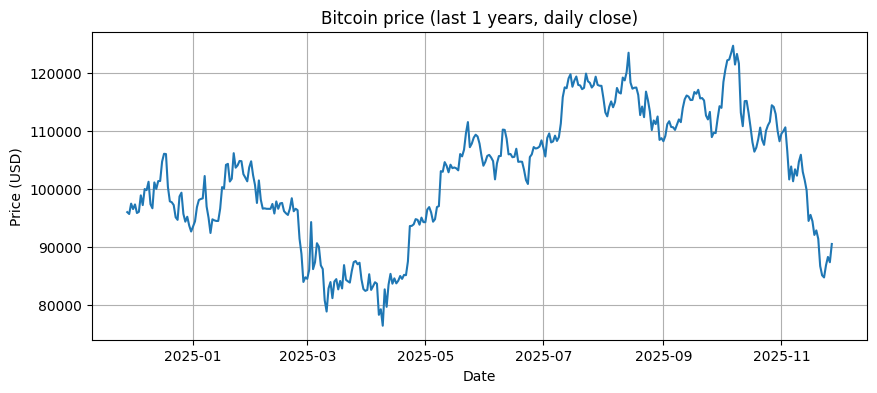

In [463]:
# 2) 간단한 시계열 시각화
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["price_usd"])
plt.title("Bitcoin price (last 1 years, daily close)")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [464]:
btc = df.copy() #깊은 복사

In [465]:
# 아리마 모델로 학습시켜보시고, 예측해보세요.
# 앞으로 30일을 예측해보세요.

In [466]:
# 1. arima객체 생성, series를 학습할 예정, (1,1,1)
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(btc, order=(1,1,1))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [467]:
# 2. 학습시킴
fit = model.fit()

In [468]:
# 3. 앞으로 30일치 예측
forecast_res = fit.get_forecast(steps=30)

In [469]:
# 4. 전체 예측한 결과 conf_int에 넣음.
conf_int = forecast_res.conf_int()

In [470]:
conf_int['yhat'] = (conf_int['upper price_usd']+conf_int['lower price_usd'])/2

In [471]:
conf_int.tail(2)

,lower price_usd,upper price_usd,yhat
2025-12-26,67570.155605,113306.252014,90438.20381
2025-12-27,67179.393252,113697.014369,90438.20381


In [472]:
conf_int.index

DatetimeIndex(['2025-11-28', '2025-11-29', '2025-11-30', '2025-12-01',
               '2025-12-02', '2025-12-03', '2025-12-04', '2025-12-05',
               '2025-12-06', '2025-12-07', '2025-12-08', '2025-12-09',
               '2025-12-10', '2025-12-11', '2025-12-12', '2025-12-13',
               '2025-12-14', '2025-12-15', '2025-12-16', '2025-12-17',
               '2025-12-18', '2025-12-19', '2025-12-20', '2025-12-21',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27'],
              dtype='datetime64[ns]', freq='D')

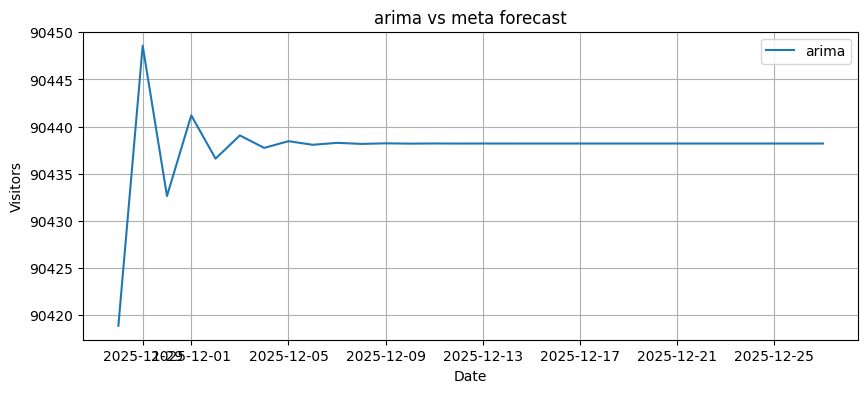

In [473]:
# arima
plt.figure(figsize=(10,4))
plt.plot(conf_int.index, conf_int['yhat'], label="arima")
plt.title("arima vs meta forecast")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.legend() #범례
plt.grid(True)
plt.show()

In [474]:
# 메타모델로 학습시켜보시고, 예측해보세요.
# 앞으로 30일을 예측해보세요.

# 메타모델은 인덱스를 날짜로 설정하지 않고, ds컬럼으로 설정해야함.
# 값은 y컬럼에 들어가 있어야함.

In [475]:
from prophet import Prophet

In [476]:
df.reset_index(inplace=True)
df.head()

,date,price_usd
0,2024-11-28,95981.180572
1,2024-11-29,95661.595958
2,2024-11-30,97453.247345
3,2024-12-01,96513.142347
4,2024-12-02,97311.707191


In [477]:
df.columns = ['ds', 'y']
df.head()

,ds,y
0,2024-11-28,95981.180572
1,2024-11-29,95661.595958
2,2024-11-30,97453.247345
3,2024-12-01,96513.142347
4,2024-12-02,97311.707191


In [478]:
m = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
m.fit(df)

In [479]:
future = m.make_future_dataframe(periods=30, freq='D')

In [480]:
forecast = m.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-11-28,98116.879712,92916.742795,99942.565320,98116.879712,98116.879712,-1552.537305,-1552.537305,-1552.537305,8777.111084,...,499.336493,499.336493,499.336493,-10828.984882,-10828.984882,-10828.984882,0.0,0.0,0.0,96564.342407
1,2024-11-29,98092.627978,92852.037955,99597.580710,98092.627978,98092.627978,-1968.615081,-1968.615081,-1968.615081,8777.111084,...,-14.054677,-14.054677,-14.054677,-10731.671488,-10731.671488,-10731.671488,0.0,0.0,0.0,96124.012897
2,2024-11-30,98068.376245,92490.830889,99575.049895,98068.376245,98068.376245,-1976.863949,-1976.863949,-1976.863949,8777.111084,...,-208.965708,-208.965708,-208.965708,-10545.009325,-10545.009325,-10545.009325,0.0,0.0,0.0,96091.512296
3,2024-12-01,98044.124511,92899.498171,99626.012472,98044.124511,98044.124511,-1732.505660,-1732.505660,-1732.505660,8777.111084,...,-229.745817,-229.745817,-229.745817,-10279.870926,-10279.870926,-10279.870926,0.0,0.0,0.0,96311.618852
4,2024-12-02,98019.872778,93294.766789,100435.435668,98019.872778,98019.872778,-1155.864988,-1155.864988,-1155.864988,8777.111084,...,15.569132,15.569132,15.569132,-9948.545205,-9948.545205,-9948.545205,0.0,0.0,0.0,96864.007789


In [481]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
390,2025-12-23,88658.698274,86153.348713,93377.931777,88658.698117,88658.698448,1064.983213,1064.983213,1064.983213,8777.111084,...,46.072823,46.072823,46.072823,-7758.200694,-7758.200694,-7758.200694,0.0,0.0,0.0,89723.681487
391,2025-12-24,88634.446515,85536.617522,92654.874681,88634.446347,88634.446702,476.829715,476.829715,476.829715,8777.111084,...,-108.212245,-108.212245,-108.212245,-8192.069124,-8192.069124,-8192.069124,0.0,0.0,0.0,89111.276230
392,2025-12-25,88610.194756,85899.113957,92810.738012,88610.194576,88610.194956,645.345862,645.345862,645.345862,8777.111084,...,499.336493,499.336493,499.336493,-8631.101715,-8631.101715,-8631.101715,0.0,0.0,0.0,89255.540618
393,2025-12-26,88585.942997,84776.690901,91845.124402,88585.942805,88585.943206,-300.170386,-300.170386,-300.170386,8777.111084,...,-14.054677,-14.054677,-14.054677,-9063.226793,-9063.226793,-9063.226793,0.0,0.0,0.0,88285.772611
394,2025-12-27,88561.691238,84335.077352,91144.977709,88561.691037,88561.691460,-908.456034,-908.456034,-908.456034,8777.111084,...,-208.965708,-208.965708,-208.965708,-9476.601410,-9476.601410,-9476.601410,0.0,0.0,0.0,87653.235203


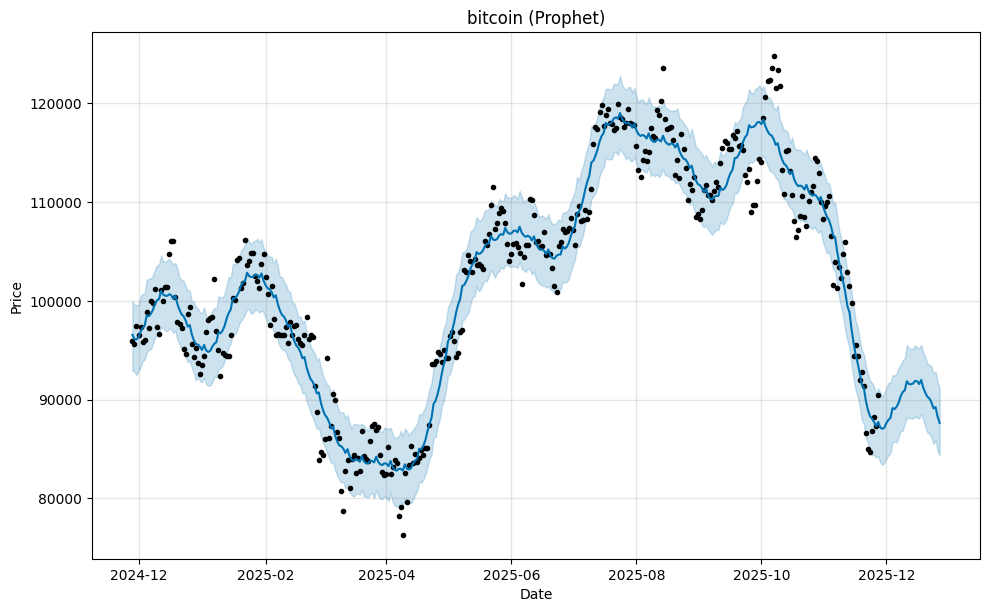

In [482]:
# 5) 전체 예측 플롯
fig1 = m.plot(forecast)
plt.title("bitcoin (Prophet)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [483]:
meta = forecast[['ds','yhat', 'yhat_lower', 'yhat_upper']].tail(30)
meta.head()

,ds,yhat,yhat_lower,yhat_upper
365,2025-11-28,87189.813090,83660.695269,90755.526786
366,2025-11-29,87044.120035,83403.980895,90269.620351
367,2025-11-30,87164.370860,83620.822570,90697.198225
368,2025-12-01,87632.055127,84009.081300,91153.964076
369,2025-12-02,87954.304301,84366.978014,91732.720826


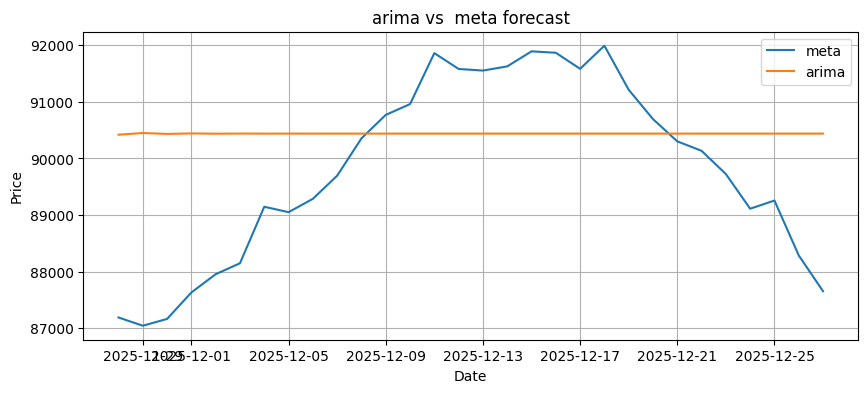

In [484]:
# arima와 meta 비교(평균가, 최고가 비교 그래프)
plt.figure(figsize=(10,4))
plt.plot(meta['ds'], meta['yhat'], label="meta")
plt.plot(conf_int.index, conf_int['yhat'], label="arima")
plt.title("arima vs  meta forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend() #범례
plt.grid(True)
plt.show()